# **Imports section**


In [1]:
import torch
import torch.nn.functional as F
import json, os, random
from math import ceil
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from datasets import load_dataset, Dataset
from transformers import EarlyStoppingCallback
from sentence_transformers.sentence_transformer.evaluation import SentenceEvaluator
from sentence_transformers import (SentenceTransformer,
                                   SentenceTransformerTrainer,
                                   SentenceTransformerTrainingArguments,
                                   CrossEncoder,
                                   CrossEncoderTrainer,
                                   CrossEncoderTrainingArguments,
                                   losses)

/tmp/ipykernel_441/2417811921.py:12: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import (SentenceTransformer,


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# The seed is for reproducibility
random.seed(42)
torch.manual_seed(42)
np.random.seed(42)


Device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Data preprocessing**
Loading the dataset and splitting the train one in train/dev with 90/10 ratio.

In [4]:
ds = load_dataset("sapienzanlp-course-materials/hw-mnlp-2026")

# Splitting the given dataset in 90/10 train/dev
train_dev_split = ds['train'].train_test_split(test_size=0.1, seed=42)
ds_train = train_dev_split['train']
ds_dev = train_dev_split['test']
ds_test = ds['test']
ds_blind = ds['blind']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.7M [00:00<?, ?B/s]

data/blind-00000-of-00001.parquet:   0%|          | 0.00/10.9M [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/66.6M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating blind split:   0%|          | 0/1322 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/8000 [00:00<?, ? examples/s]

# **General Purposes Helpers**

Here we define a few helper functions. In particular:
- **`embed_batch`**: embeds a single batch with a given encoder model. It first encodes all the queries together, then flattens the candidate chunks and encodes them.
- **`preprocess_data`**: embeds the entire dataset by splitting it into batches and iteratively applying `embed_batch`.
- **`get_ranks`**: given the embedded dataset, it returns two different outputs:
  - **ranks**: a *list* where the single item `i` is the rank of the answer in of the `i-th` query (used to compute MRR and Hit@k);
  - **similarity_ladder**: a *dictionary* where each key is a query_id and each value is a list of candidate chunk IDs, ordered by similarity ranking. The position of each chunk id in the list corresponds to its rank for that query (used for the production of jsonl files).
- **`produce_jsonl`**: given the similarity ladder it produces the jsonl file.
- **`plot_metric_bar_graph`**: given a list of dictionaries, where each dictionary contains a *metric record* (metric values for a single model), it plots a bar chart (grouped or not) to compare the metric across models.
- **`plot_metric_delta_from_baseline`**: given a baseline model record and a list of *metric records*, it computes the percentage change in metric values relative to the baseline and plots them in a bar chart, with the baseline fixed at 0%.
- **`make_hit_metric_record`**: format a metric record for the plotting of *hit@k*.
- **`make_mrr_metric_record`**: format a metric record for the plotting of *mrr*.


In [5]:
# This function performs batch embedding of queries and candidate chunks.
# Precomputing embeddings speeds up the retrieval metrics computation.
def embed_batch(batch, model, log_info, batch_size=64):
    """
    Embed a batch of examples using the given model. Done to improve encoding speed.
    """

    q_embs = model.encode(
        batch["query"],
        batch_size=batch_size,
        convert_to_tensor = True,
    )

    # Flattening consecutive candidate chunks to aggregate them in a single batch
    lengths = batch["n_candidates"]
    flat_candidates = []
    for cands in batch["candidate_chunks"]:
        for chunk in cands:
            flat_candidates.append(chunk)

    flat_cand_embs = model.encode(
        flat_candidates,
        batch_size=batch_size,
        convert_to_tensor = True,
    )

    loading_bar = log_info["loading_bar"]
    loading_bar.update(1)

    # Reshaping chunk embeddings in the original chunk group
    cand_embs = []
    start = 0
    for n in lengths:
        cand_embs.append(flat_cand_embs[start:start + n])
        start += n

    emb_batch = {
        "q_emb": q_embs,
        "query_id": batch["query_id"],
        "cand_embs": cand_embs,
    }

    # Keep answer_pos only when the current batch provides it.
    # This lets the helper work for both evaluated splits and blind-style batches.
    if "answer_pos" in batch:
        emb_batch["answer_pos"] = batch["answer_pos"]

    return emb_batch

# This function wraps the usage of the `embed_batch` function in order to precompute
# the embedded dataset
def preprocess_data(model, dataset, split_name = None, batch_size = 64):
    """
    Prepare an embedded version of the dataset.
    """

    # In inference time is importat to activate evaluation mode of the model
    model.eval()
    with torch.no_grad():
        if split_name is not None:
            dataset = dataset[split_name]

        emb_dataset = []

        log_info = {}
        log_info["tot_batches"] = ceil(len(dataset) / batch_size)
        loading_bar = tqdm(total=log_info["tot_batches"], desc="Encoding")
        log_info["loading_bar"] = loading_bar

        # Slicing the dataset in batch and iteratively embed them with the helper `embed_batch`.
        # Note: this operation could also be implemented with dataset.map(embed_batch, ...).
        # However, using the model inside the function passed to map() gets stuck the execution of the cell,
        # so we process the dataset explicitly in batches instead.
        for i in range(0, len(dataset), batch_size):
            batch = dataset[i:i + batch_size]
            emb_batch = embed_batch(batch, model, log_info, batch_size)

            for j in range(len(emb_batch["q_emb"])):
                data = {
                    "q_emb": emb_batch["q_emb"][j],
                    "query_id": emb_batch["query_id"][j],
                    "cand_embs": emb_batch["cand_embs"][j],
                }

                # For the blind split, ranks are not computed, so answer_pos is intentionally skipped.
                if split_name != "blind":
                    data["answer_pos"] = emb_batch["answer_pos"][j]

                emb_dataset.append(data)

        loading_bar.close()

    return emb_dataset

def get_ranks(emb_dataset):
    """
    Compute the ranks of the correct answers for all queries in the dataset.
    Returns a list of integers [r_1, ..., r_n], where r_i is the rank of the
    correct answer for query `i` after sorting its candidate chunks by similarity score and
    the similarity ladder, that are the ranked similarity scores for each query.
    """
    ranks = []
    sim_ladder = {}

    for data in emb_dataset:

        q_emb = data["q_emb"]
        cands_emb = data["cand_embs"]
        qid = data["query_id"]

        scores = F.cosine_similarity(q_emb, cands_emb)

        ranked_idx = torch.argsort(scores, descending=True).tolist()

        # The similarity ladder is used to produce the jsonl output files.
        sim_ladder[qid] = ranked_idx

        # Compute ranks only for embedded examples that carry a usable answer_pos.
        if "answer_pos" in data:
            answer_pos = data["answer_pos"]
            rank = ranked_idx.index(answer_pos)  + 1
            ranks.append(rank)

    return ranks, sim_ladder # ranks shape: [N], N number of queries

In [6]:
# Helper to produce jsonl files
def produce_jsonl(sim_ladder, filename):

    output_dir = "/content/drive/MyDrive/MNLP_HW1_outputs"
    os.makedirs(output_dir, exist_ok=True)
    path = os.path.join(output_dir, filename)

    with open(path, "w") as f:
        for query_id, chunk_ids in sim_ladder.items():
            row = {
                str(query_id): [int(chunk_id) for chunk_id in chunk_ids],
            }
            f.write(json.dumps(row) + "\n")


# Helper to plot comparable metrics across models or setups
def plot_metric_bar_graph(metric_records):

    metric_names = [metric["metric_name"] for metric in metric_records[0]["metrics"]]

    model_names = [record["model_name"] for record in metric_records]
    x_positions = np.arange(len(model_names))
    bar_width = 0.8 / len(metric_names)

    fig, ax = plt.subplots(figsize = (10, 5))

    # for each metric value we compute the bar
    for i, metric_name in enumerate(metric_names):
        metric_values = [float(record["metrics"][i]["metric_value"]) for record in metric_records]
        bar_positions = x_positions + (i - (len(metric_names) - 1) / 2) * bar_width
        bars = ax.bar(bar_positions, metric_values, width = bar_width, label = metric_name)
        ax.bar_label(bars, fmt = "%.4f", padding = 0.5)

    # Chart layout definition
    ax.set_title("Metrics comparison")
    ax.set_xlabel("Model")
    ax.set_ylabel("Metric value")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(model_names)
    ax.legend(title = "Metric")
    ax.grid(axis = "y", alpha = 0.3)
    ax.tick_params(axis = "x", rotation = 30)
    ax.set_ylim(0, max(
        float(metric["metric_value"])
        for record in metric_records
        for metric in record["metrics"]
    ) * 1.1)

    fig.tight_layout()
    plt.show()

    return fig, ax


def plot_metric_delta_from_baseline(baseline_metric, metric_records):

    metric_names = [m["metric_name"] for m in baseline_metric["metrics"]]
    baseline_values = [float(m["metric_value"]) for m in baseline_metric["metrics"]]

    x = np.arange(len(metric_names))
    width = 0.8 / len(metric_records)

    fig, ax = plt.subplots(figsize=(10, 5))

    # deltas initialization
    all_deltas = []

    for i, record in enumerate(metric_records):
        values = [float(m["metric_value"]) for m in record["metrics"]]
        # computation of the percentage variation wrt the baseline
        deltas = [100 * (v - b) / b for v, b in zip(values, baseline_values)]
        all_deltas.extend(deltas)

        positions = x + (i - (len(metric_records) - 1) / 2) * width
        bars = ax.bar(positions, deltas, width=width, label=record["model_name"])

        for bar, delta in zip(bars, deltas):
            y = delta + 0.5 if delta >= 0 else delta - 0.5
            va = "bottom" if delta >= 0 else "top"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                f"{delta:.1f}%",
                ha="center",
                va=va,
                fontsize=9
            )

    pad = max(max(map(abs, all_deltas)) * 0.15, 1) if all_deltas else 1
    ymin = min(all_deltas) - pad if all_deltas else -1
    ymax = max(all_deltas) + pad if all_deltas else 1

    ax.axhline(0, color="black", linewidth=1)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f"Metric variation vs {baseline_metric['model_name']}")
    ax.set_xlabel("Metric")
    ax.set_ylabel("Variation from baseline (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names)
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.legend(title="Model")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()
    plt.show()

    return fig, ax

# Helper to produce te input for the plot functions
def make_hit_metric_record(model_name, hits_at_k, k_s):
    return {
        "model_name": model_name,
        "metrics": [
            {"metric_name": f"Hit@{k}", "metric_value": hits_at_k[k]}
            for k in k_s
        ],
    }

def make_mrr_metric_record(model_name, mrr_value):
    return {
        "model_name": model_name,
        "metrics": [{"metric_name": "MRR", "metric_value": mrr_value}]
    }

# **Evaluation Metrics**

In this notebook section we are going to define two different retrievial evaluation metrics:
- $Hit@k$
- $MRR$

### **Hit@k**

Hit@k is a metric used to evaluate the accuracy of retrieval systems. It measures whether the correct answer is present among the top k chunks recommended by the system. If the relevant item (the *answer*) is found within the top k results, it's considered a **hit**.

The formula for Hit@k is:

$$Hit@k = \frac{1}{N} \sum_{i = 1}^{N} \mathbb{I}[rank_i \leq k]$$

where:
- $\mathbb{I}$ is the indicator function;
- $k$ is the size of the top ranked window within which the correct answer is considered a hit;
- $rank_i$ is the rank of the first relevant chunk for the $i$-th query.

In [7]:
# We fix hit@k for k = 1, 3, 5.
k_s = [1, 3, 5]
def compute_hit_at_k(k, ranks):
    """
    Compute the Hit@k metric for a given value of k. It accepts the ranks returned by `get_ranks`.
    """
    hits = []

    for rank in ranks:
        hit = 1.0 if rank <= k else 0.0
        hits.append(hit)

    return float(np.mean(hits))

def compute_multiple_hit_at_k(k_s, ranks):
    """
    Compute multiple istances of Hit@k for different values of k.
    """
    values = {}

    for k in k_s:
        values[k] = compute_hit_at_k(k, ranks)

    return values


### **MRR**

This metric assesses the effectiveness of an information retrieval system by giving higher scores to systems that rank relevant items higher. It is calculated as the average of the reciprocal ranks of the answer for a set of queries.

The formula for MRR is:

$$MRR = \frac{1}{N} \sum_{i=1}^{N} \frac{1}{rank_i}$$

where:
- $N$ is the total number of queries.
- $rank_i$ is the rank of the first relevant chunk for the $i$-th query.

In [8]:
def compute_mrr(ranks):
    """
    Very straightforward function. It implements the MRR metric by computing reciprocal ranks and
    performing the mean.
    """
    reciprocal_ranks = []

    for rank in ranks:
        rr = 1.0 / rank
        reciprocal_ranks.append(rr)

    return float(np.mean(reciprocal_ranks))

# **Baseline models + evaluations**

Now we are going to compute the baseline values for MRR and Hit@k for the chosen baseline models:
- `distilbert-base-uncased` (base requirement)
- `all-MiniLM-L6-v2` (base requirement)
- `all-mpnet-base-v2` (additional)

In [9]:
# Loading of the baseline models: distilbert, minilm, mpnet (the latter is an additional one)
bert_baseline_model = SentenceTransformer("distilbert-base-uncased")
bert_baseline_model.to(device)

MiniLM_baseline_model = SentenceTransformer("all-MiniLM-L6-v2")
MiniLM_baseline_model.to(device)

mpnet_baseline_model = SentenceTransformer("all-mpnet-base-v2")
mpnet_baseline_model.to(device)

# Precomputing embeddings with the baseline models and getting free the gpu memory
bert_emb_dataset = preprocess_data(
    model = bert_baseline_model,
    dataset = ds,
    split_name = "test",
)

del bert_baseline_model
torch.cuda.empty_cache()

MiniLM_emb_dataset = preprocess_data(
    model = MiniLM_baseline_model,
    dataset = ds,
    split_name = "test",
)

del MiniLM_baseline_model
torch.cuda.empty_cache()

mpnet_emb_dataset = preprocess_data(
    model = mpnet_baseline_model,
    dataset = ds,
    split_name = "test",
)

del mpnet_baseline_model
torch.cuda.empty_cache()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding:   0%|          | 0/32 [00:00<?, ?it/s]

Encoding:   0%|          | 0/32 [00:00<?, ?it/s]

Encoding:   0%|          | 0/32 [00:00<?, ?it/s]

The reference values for the baseline models are:

\begin{array}{lccc}
\hline
\textbf{Model} & \textbf{Hit@1} & \textbf{Hit@3} & \textbf{Hit@5} \\
\hline
\text{distilbert-base-uncased} & 0.1765 & 0.4435 & 0.6045 \\
\text{all-MiniLM-L6-v2} & 0.4480 & 0.7165 & 0.8080 \\
\hline
\end{array}


In [10]:
# Retrieving ranks (in this phase we don't need similarity ladder, which is instead used to produce jsonl files)
bert_ranks, _ = get_ranks(bert_emb_dataset)
MiniLM_ranks, _ = get_ranks(MiniLM_emb_dataset)
mpnet_ranks, _ = get_ranks(mpnet_emb_dataset)

# Compute MRR with the baseline models
bert_baseline_mrr = compute_mrr(
    ranks = bert_ranks,
)

MiniLM_baseline_mrr = compute_mrr(
    ranks = MiniLM_ranks,
)

mpnet_baseline_mrr = compute_mrr(
    ranks = mpnet_ranks,
)

# Compute hit@k with the baseline models
bert_baseline_hits_at_k = compute_multiple_hit_at_k(
    ranks = bert_ranks,
    k_s = k_s,
)

MiniLM_baseline_hits_at_k = compute_multiple_hit_at_k(
    ranks = MiniLM_ranks,
    k_s = k_s,
)

mpnet_baseline_hits_at_k = compute_multiple_hit_at_k(
    ranks = mpnet_ranks,
    k_s = k_s,
)

print("Baseline Model: distilbert-base-uncased")
print(f"Baseline MRR: {bert_baseline_mrr:.4f}")
print("Baseline Hit@k:")
print(
    f"k = 1: {bert_baseline_hits_at_k[1]:.4f} | "
    f"k = 3: {bert_baseline_hits_at_k[3]:.4f} | "
    f"k = 5: {bert_baseline_hits_at_k[5]:.4f}"
)

print("Baseline Model: all-MiniLM-L6-v2")
print(f"Baseline MRR: {MiniLM_baseline_mrr:.4f}")
print("Baseline Hit@k:")
print(
    f"k = 1: {MiniLM_baseline_hits_at_k[1]:.4f} | "
    f"k = 3: {MiniLM_baseline_hits_at_k[3]:.4f} | "
    f"k = 5: {MiniLM_baseline_hits_at_k[5]:.4f}"
)

print("Baseline Model: all-mpnet-base-v2")
print(f"Baseline MRR: {mpnet_baseline_mrr:.4f}")
print("Baseline Hit@k:")
print(
    f"k = 1: {mpnet_baseline_hits_at_k[1]:.4f} | "
    f"k = 3: {mpnet_baseline_hits_at_k[3]:.4f} | "
    f"k = 5: {mpnet_baseline_hits_at_k[5]:.4f}"
)

Baseline Model: distilbert-base-uncased
Baseline MRR: 0.3657
Baseline Hit@k:
k = 1: 0.1765 | k = 3: 0.4435 | k = 5: 0.6045
Baseline Model: all-MiniLM-L6-v2
Baseline MRR: 0.6093
Baseline Hit@k:
k = 1: 0.4480 | k = 3: 0.7165 | k = 5: 0.8080
Baseline Model: all-mpnet-base-v2
Baseline MRR: 0.6611
Baseline Hit@k:
k = 1: 0.5110 | k = 3: 0.7650 | k = 5: 0.8540


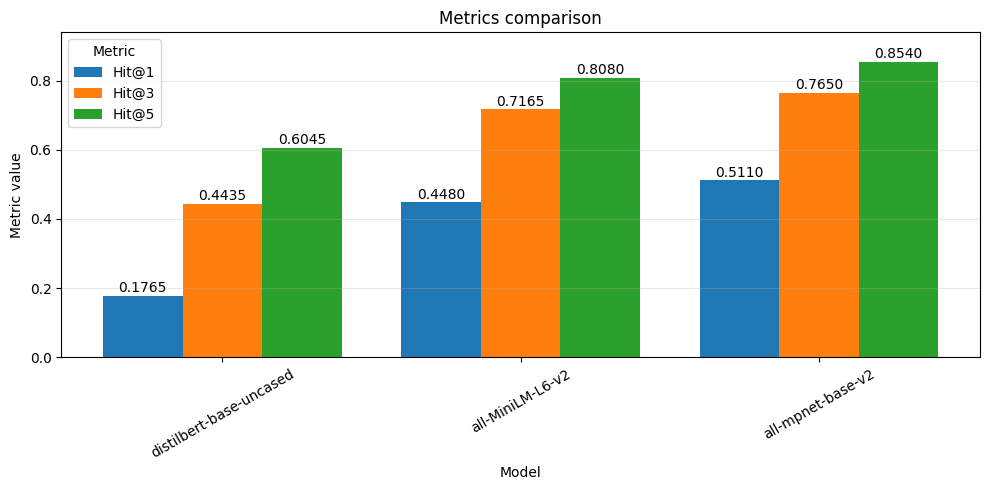

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Metrics comparison'}, xlabel='Model', ylabel='Metric value'>)

In [11]:
# Hit@k comparison between baseline models
baseline_hit_records = [
    make_hit_metric_record("distilbert-base-uncased", bert_baseline_hits_at_k, k_s),
    make_hit_metric_record("all-MiniLM-L6-v2", MiniLM_baseline_hits_at_k, k_s),
    make_hit_metric_record("all-mpnet-base-v2", mpnet_baseline_hits_at_k, k_s),
]

plot_metric_bar_graph(baseline_hit_records)


# **Evaluator for training**

The evaluator measures the performance of the finetuned model by computing:
- the $MRR$
- the $Hit@k$ with $k \in \{1, 3, 5\}$

These metrics are used during training to monitor retrieval quality and decide when to stop training. In particular, we use MRR as the early stopping metric because it provides a more informative signal than Hit@k: while Hit@k only checks whether the correct chunk appears within the top-$k$ results, MRR also takes into account its exact ranking position. This makes it more sensitive to improvements in ranking quality.

In [12]:
# The evaluator is used during the training phase to keep track of both evaluation metrics: MRR and Hit@k
class Evaluator(SentenceEvaluator):

    # The batch size is only to improve speed in encoding of chunks
    def __init__(self, dataset, name = None):
        self.dataset = dataset
        self.name = name

    def __call__(self, model, output_path=None, epoch: int = -1, steps: int = -1):

        # Preprocess embeddings inside the evaluator to use the current model
        emb_dataset = preprocess_data(
            model = model,
            dataset = self.dataset,
        )

        ranks, _ = get_ranks(emb_dataset)

        mrr = compute_mrr(
            ranks = ranks,
        )

        k_s = [1, 3, 5]
        hits_at_k = compute_multiple_hit_at_k(
            ranks = ranks,
            k_s = k_s,
        )

        metrics = {"eval_mrr": mrr}
        for k, hit_value in hits_at_k.items():
            metrics[f"eval_hit@{k}"] = hit_value

        return metrics

# **1. [FT-InB] Explicit Negatives + In Batch Negatives Finetuning**
In this scenario, we finetune the model composing the *training tuples* in this way:
- An anchor (the query)
- 1 positive (the answer)
- 3 in sample explicit negatives randomly picked from the query's candidate chunks set (more challenging than unrelated negatives as the in-batch ones)
- In batch negatives.

The used loss is `MNRL` with default parameters.

In [13]:
# This function prepares the dataset to finetune the model with the in-batch negatives strategy.
# For each query, it keeps the answer as positive and samples 3 random negatives.
def prepare_item(data):
    negatives = [c for c in data["candidate_chunks"] if c != data["answer"]]
    random.shuffle(negatives)
    negatives = negatives[:3]
    item = {
        "anchor": data["query"],
        "positive": data["answer"],
    }

    for i, neg in enumerate(negatives):
        item[f"negative_{i}"] = neg
    return item

## **1.1 FT-InB Finetuning settings**

In [14]:
FT_InB_ds_train = ds_train.map(prepare_item, remove_columns=ds_train.column_names)
FT_InB_ds_dev = ds_dev.map(prepare_item, remove_columns=ds_dev.column_names)

# Instantiate the model
st_ft_model = SentenceTransformer("distilbert-base-uncased")
st_ft_model.to(device)

# Instantiate the evaluator
evaluator = Evaluator(ds_dev)

loss = losses.MultipleNegativesRankingLoss(
    model = st_ft_model,
)

# Training arguments
training_args = SentenceTransformerTrainingArguments(
    output_dir = "weights/in-batch-negatives",
    num_train_epochs = 5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    learning_rate = 2e-5,
    weight_decay = 0.001,

    eval_strategy = "epoch",
    save_strategy = "epoch",
    logging_steps = 50,

    load_best_model_at_end=True,
    metric_for_best_model = "eval_mrr",
    greater_is_better = True,

    warmup_steps = 0.1,
)

# Instantiate the trainer
# Notice that the optimizer is not explicitly chosen. By default, AdamW is used.
trainer = SentenceTransformerTrainer(model = st_ft_model,
                                     args = training_args,
                                     train_dataset = FT_InB_ds_train,
                                     eval_dataset = FT_InB_ds_dev,
                                     evaluator = evaluator,
                                     loss = loss,
                                     callbacks = [EarlyStoppingCallback(early_stopping_patience=2)]
                                     # Early stopping callback stops the execution if the chosen metric
                                     # doesn't improve after `early_stopping_patience` evaluation steps
                                     # (defined in the `eval_strategy` field).
                                     )
trainer.train()

Map:   0%|          | 0/7200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding:   0%|          | 0/13 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

TrainOutput(global_step=1350, training_loss=0.45726792794686777, metrics={'train_runtime': 2714.0041, 'train_samples_per_second': 13.265, 'train_steps_per_second': 0.829, 'total_flos': 0.0, 'train_loss': 0.45726792794686777, 'epoch': 3.0})

In [15]:
# Here we are computing the embedded dataset with the `st_ft_model`, to retrieve ranks, metrics and to produce jsonl output files
# for both test and blind dataset. This is the first time that this model processes the test set.
st_test_emb_dataset = preprocess_data(
    model = st_ft_model,
    dataset = ds,
    split_name = "test"
)

st_blind_emb_dataset = preprocess_data(
    model = st_ft_model,
    dataset = ds,
    split_name = "blind",
)

Encoding:   0%|          | 0/32 [00:00<?, ?it/s]

Encoding:   0%|          | 0/21 [00:00<?, ?it/s]

## **1.2 Evaluation of FT-InB over test set**
In this section, we evaluate the finetuned model on the test set for the first time. This evaluation is used only for reporting purposes and does not influence any training decision.

In [16]:
# Retrieving ranks and similarity ladders for test and blind splits.
# The blind split has a dummy answer_pos value, so only its similarity ladder is used.
st_test_ranks, st_test_sim_ladder = get_ranks(st_test_emb_dataset)
_, st_blind_sim_ladder = get_ranks(st_blind_emb_dataset)

st_mrr = compute_mrr(
    ranks = st_test_ranks,
)

st_hits_at_k = compute_multiple_hit_at_k(
    ranks = st_test_ranks,
    k_s = k_s,
)

# Logging phase
print("Finetuned Model: distilbert-base-uncased finetuned with in-batch negatives")
print(f"Finetuned Model MRR: {st_mrr:.4f}")
print("Finetuned Model Hit@k:")
print(
    f"k = 1: {st_hits_at_k[1]:.4f} | "
    f"k = 3: {st_hits_at_k[3]:.4f} | "
    f"k = 5: {st_hits_at_k[5]:.4f} | "
)

produce_jsonl(st_test_sim_ladder, "TheOverfitters-test-distilbert_base_uncased-FT_InB.jsonl")
produce_jsonl(st_blind_sim_ladder, "TheOverfitters-blind-distilbert_base_uncased-FT_InB.jsonl")

Finetuned Model: distilbert-base-uncased finetuned with in-batch negatives
Finetuned Model MRR: 0.7075
Finetuned Model Hit@k:
k = 1: 0.5675 | k = 3: 0.8195 | k = 5: 0.8925 | 


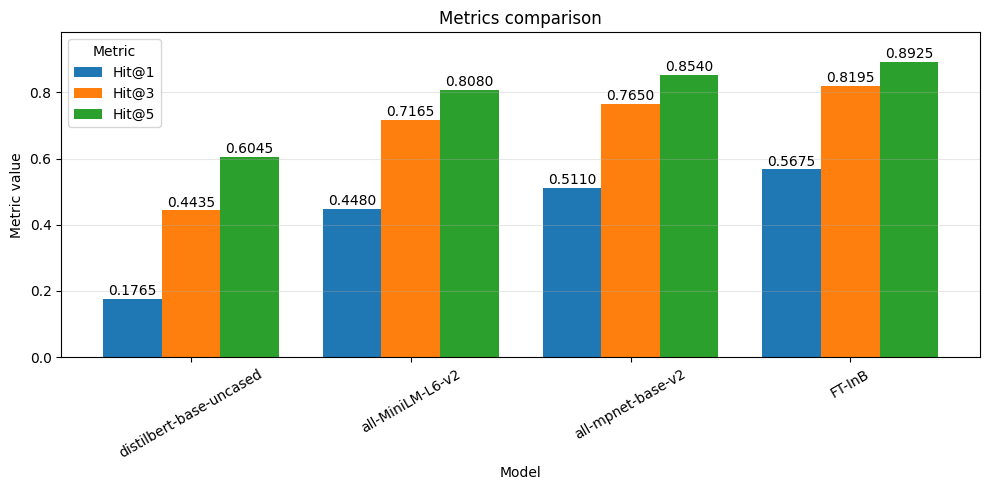

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Metrics comparison'}, xlabel='Model', ylabel='Metric value'>)

In [17]:
# Hit@k comparison between baseline models and in-batch negatives finetuning
FT_InB_hit_records = baseline_hit_records + [
    make_hit_metric_record("FT-InB", st_hits_at_k, k_s),
]

plot_metric_bar_graph(FT_InB_hit_records)


# **2. [FT-HN] Explicit Hard Negatives + In Batch Negatives Finetuning**
In this scenario, we train our model by composing the *training tuples* in this way:
- An anchor (the query)
- 1 positive (the answer)
- Up to 5 explicit hard negatives, picked from the top 5 chunks ranked by the previous finetuned model (*FT-InB*);
- In-batch negatives.

The used loss is `MNRL` with two explicit parameters:
- `hardness_mode` = "hard_negatives"
- `hardness_strength` = 0.1

## **2.1 Data preprocessing pipeline**
The training pipeline for this setting requires:


1. Embed the train and dev splits using the FT-InB (already finetuned) retriever model.
2. Rank the candidate chunks for each query in the train and dev splits by computing similarity scores between the query embedding and the corresponding candidate chunk embeddings.
3. Select the top-5 candidates for each query based on the resulting ranking.
4. Build new train and dev datasets by constructing training tuples from the top-5 retrieved candidates according to the training tuple composition defined above.
5. Use the resulting train and dev datasets as input to FT-HN.


In [18]:
# Preparing the dataset for the Hard Negatives setup.
# Hard negatives are selected from the top-k chunks in the provided similarity ladder,
# excluding the gold answer when it appears in those top-k chunks.
def prepare_dataset(ds, sim_ladder, k=5):
    """
    Helper to build the dataset for the Hard Negatives setup.
    """
    dataset = []

    for data in ds:
        qid = data["query_id"]
        answer_pos = int(data["answer_pos"])

        hard_neg = [
            data["candidate_chunks"][i]
            for i in sim_ladder[qid][:k]
            if i != answer_pos
        ]

        # Each element of the dataset has an anchor, a positive and the selected hard negatives.
        item = {
            "anchor": data["query"],
            "positive": data["answer"],
        }

        for i, hneg in enumerate(hard_neg):
            item[f"negative_{i}"] = hneg


        dataset.append(item)

    return Dataset.from_list(dataset)

In [19]:
# Precomputing the embedded version of both train and dev sets
hard_neg_train_emb_dataset = preprocess_data(
    model = st_ft_model,
    dataset = ds_train,
)

hard_neg_dev_emb_dataset = preprocess_data(
    model = st_ft_model,
    dataset = ds_dev,
)

_, hard_neg_train_sim_ladder = get_ranks(hard_neg_train_emb_dataset)
_, hard_neg_dev_sim_ladder = get_ranks(hard_neg_dev_emb_dataset)

# Preparing the dataset
HN_ds_train = prepare_dataset(ds_train, hard_neg_train_sim_ladder)
HN_ds_dev = prepare_dataset(ds_dev, hard_neg_dev_sim_ladder)

# Instantiate the model
HN_ft_model = SentenceTransformer("distilbert-base-uncased")
HN_ft_model.to(device)

# Instantiate the evaluator
evaluator = Evaluator(ds_dev)

del st_ft_model
torch.cuda.empty_cache()


Encoding:   0%|          | 0/113 [00:00<?, ?it/s]

Encoding:   0%|          | 0/13 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## **2.2 FT-HN Finetuning settings**
As suggested in the documentation, MNRL is well suited to this scenario. In particular, it allows us to use `hardness_mode = "hard_negatives"`, so that hard negatives are weighted differently from the in batch negatives by tuning the `hardness_strength` parameter.

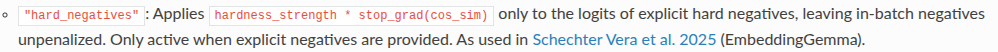

In [20]:
# As suggested in the documentation, the loss for this setup is the MultipleNegativeRankingLoss.
loss = losses.MultipleNegativesRankingLoss(
    model = HN_ft_model,
    hardness_mode = "hard_negatives",
    hardness_strength = 0.1,
)

In [21]:
# Training arguments
training_args = SentenceTransformerTrainingArguments(
    output_dir = "weights/Hard_negatives",
    num_train_epochs = 5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    learning_rate = 2e-5,
    weight_decay = 0.001,

    eval_strategy = "epoch",
    save_strategy = "epoch",
    logging_steps = 50,

    load_best_model_at_end=True,
    metric_for_best_model = "eval_mrr",
    greater_is_better = True,

    warmup_steps = 0.1
)

# Instantiate the trainer
# Notice that the optimizer is not explicitly chosen. By default, AdamW is used.
trainer = SentenceTransformerTrainer(model = HN_ft_model,
                                     args = training_args,
                                     train_dataset = HN_ds_train,
                                     eval_dataset = HN_ds_dev,
                                     evaluator = evaluator,
                                     loss = loss,
                                     callbacks = [EarlyStoppingCallback(early_stopping_patience=2)]
                                     # Early stopping callback stops the execution if the choosen metric
                                     # doesn't improve after `early_stopping_patience` evaluation steps
                                     # (defined in the `eval_strategy` field).
                                     )
# Launching the training
trainer.train()

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Epoch,Training Loss,Validation Loss,Mrr,Hit@1,Hit@3,Hit@5
1,1.363101,1.346478,0.724897,0.592500,0.826250,0.898750
2,0.894078,1.301269,0.736801,0.611250,0.826250,0.902500
3,0.496820,1.356620,0.728605,0.603750,0.822500,0.900000
4,0.283520,1.410799,0.725916,0.602500,0.820000,0.891250


Encoding:   0%|          | 0/13 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding:   0%|          | 0/13 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding:   0%|          | 0/13 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

TrainOutput(global_step=1800, training_loss=0.8458407619264391, metrics={'train_runtime': 4528.9967, 'train_samples_per_second': 7.949, 'train_steps_per_second': 0.497, 'total_flos': 0.0, 'train_loss': 0.8458407619264391, 'epoch': 4.0})

## **2.3 Evaluation of FT-HN over the test set**
In this section, we evaluate the finetuned model on the test set for the first time. This evaluation is used only for reporting purposes and does not influence any training decision.

In [22]:
# Precomputing the embedded datasets to evaluate the model
HN_test_emb_dataset = preprocess_data(
    model = HN_ft_model,
    dataset = ds,
    split_name = "test"
)

HN_blind_emb_dataset = preprocess_data(
    model = HN_ft_model,
    dataset = ds,
    split_name = "blind",
)

Encoding:   0%|          | 0/32 [00:00<?, ?it/s]

Encoding:   0%|          | 0/21 [00:00<?, ?it/s]

In [23]:
# Evaluating the model by computing MRR and Hit@k. To perform this task, we need the similarity ladder and the rank of each answer.
# Note that `HN_test_sim_ladder` and `HN_blind_sim_ladder` will be used later in the reranking stage.
HN_test_ranks, HN_test_sim_ladder = get_ranks(HN_test_emb_dataset)
_, HN_blind_sim_ladder = get_ranks(HN_blind_emb_dataset)

HN_mrr = compute_mrr(
    ranks = HN_test_ranks,
)

HN_hits_at_k = compute_multiple_hit_at_k(
    ranks = HN_test_ranks,
    k_s = k_s,
)

print("Finetuned Model: distilbert-base-uncased finetuned with HN")
print(f"Finetuned Model MRR: {HN_mrr:.4f}")
print("Finetuned Model Hit@k:")
print(
    f"k = 1: {HN_hits_at_k[1]:.4f} | "
    f"k = 3: {HN_hits_at_k[3]:.4f} | "
    f"k = 5: {HN_hits_at_k[5]:.4f} | "
)

produce_jsonl(HN_test_sim_ladder, "TheOverfitters-test-distilbert_base_uncased-FT_HN.jsonl")
produce_jsonl(HN_blind_sim_ladder, "TheOverfitters-blind-distilbert_base_uncased-FT_HN.jsonl")

Finetuned Model: distilbert-base-uncased finetuned with HN
Finetuned Model MRR: 0.7440
Finetuned Model Hit@k:
k = 1: 0.6190 | k = 3: 0.8455 | k = 5: 0.9100 | 


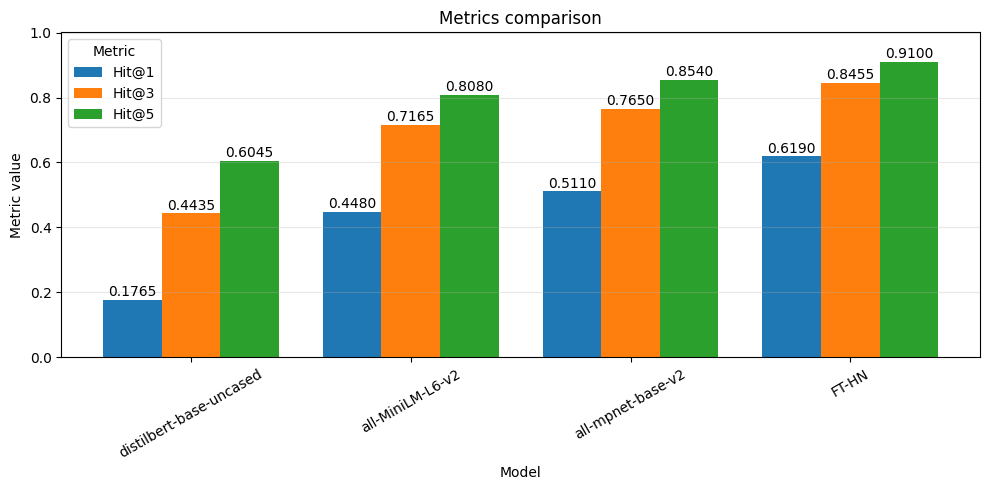

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Metrics comparison'}, xlabel='Model', ylabel='Metric value'>)

In [24]:
# Hit@k comparison between baseline models and hard negatives finetuning
FT_HN_hit_records = baseline_hit_records + [
    make_hit_metric_record("FT-HN", HN_hits_at_k, k_s),
]

plot_metric_bar_graph(FT_HN_hit_records)


# **3. [CE-RR] Reranking stage using CrossEncoder**

## **3.1 Helpers**
Here some ad hoc helpers for the crossencoder finetuning:
- **`retrieve_top_k`**: given a similarity ranking for each query, it builds a new data structure containing only the top-$k$ retrieved candidate chunks.
- **`build_topk_dataset`**: given the top-$k$ retrieved data (output of the `retrieve_top_k` function), it builds a labeled dataset for reranking finetuning. Only queries whose gold chunk appears in the retrieved top-$k$ are kept. For each of them, the gold chunk is added as a positive example, while the remaining retrieved chunks are added as negative examples.
Each training tuple will have the following shape: $(query, chunk, label)$.
- **`rerank`**: given a reranker model and the top-$k$ retrieved candidates for each query, it scores each $(query,chunk)$ pair and produces a new ranking of the top-$k$ chunks based on the reranker scores.
- **`merge_ladders`**: combines the reranked top-$k$ portion with the remaining part of the original ranking, so as to reconstruct a full ranking over all candidate chunks for each query.
- **`get_rank_from_reranked`**: given the final merged ranking, it computes the rank position of the gold chunk for each query and returns the resulting list of ranks.

In [25]:
# Retrieving top-k candidate chunks
def retrieve_top_k(sim_ladder, k, ds):
    """
    output shape:
        [{
          "query_id": query_id,
          "query": query,
          "topk_chunk_ids": [chunk_id0, chunk_id1, ...],
          "candidate_chunks": [chunk0, chunk1, ...],
          [optional]"answer_pos": answer_pos,
        }, {...}, ...]
    """
    topk = []

    id_to_item = {item["query_id"]: item for item in ds}

    # Build each top-k item as specified in the function description.
    # Here we are picking the first k items starting from the similarity ladder.
    for query_id, chunk_ids in sim_ladder.items():
        topk_chunks_id = chunk_ids[:k]
        topk_chunks = []
        item = id_to_item[query_id]

        for chunk_id in topk_chunks_id:
            topk_chunks.append(
                item["candidate_chunks"][chunk_id]
            )

        data = {
            "query_id": query_id,
            "query": id_to_item[query_id]["query"],
            "topk_chunk_ids": topk_chunks_id,
            "candidate_chunks": topk_chunks,
        }

        # Store answer_pos only when the gold answer is inside the retrieved top-k.
        if "answer_pos" in item and item["answer_pos"] in topk_chunks_id:
            data["answer_pos"] = item["answer_pos"]

        topk.append(data)

    return topk

def build_topk_dataset(topk):
    dataset = []

    # Starting from the topk dataset, we build a labeled one to perform finetuning
    for item in topk:
        # If answer_pos is not in the topk item, we just skip it
        if "answer_pos" not in item:
            continue

        answer_pos = item["answer_pos"]
        topk_ids = item["topk_chunk_ids"]

        # local_pos is the answer index inside the top k chunks list
        local_pos = topk_ids.index(answer_pos)
        answer = item["candidate_chunks"][local_pos]

        negatives = [
            c for i, c in enumerate(item["candidate_chunks"])
            if i != local_pos
        ]

        dataset.append({
            "query": item["query"],
            "chunk": answer,
            "label": 1,
        })

        for neg in negatives:
            dataset.append({
                "query": item["query"],
                "chunk": neg,
                "label": 0,
            })

    return Dataset.from_list(dataset)


def rerank(reranker, topk):

    reranked_ladder = {}

    # For each query, we compute the relevance score beteween (query, chunk) iterating over all the candidate chunks for that query.
    for item in topk:
        qnas = []
        query = item["query"]
        qid = item["query_id"]

        # We just compute a pair (query, chunk) for each candidate chunk for that query.
        # The crossencoder object has the method `predict` which takes as input sentences pairs,
        # and produces a relevance score for each pair.
        for chunk in item["candidate_chunks"]:
            qna = (query, chunk)
            qnas.append(qna)

        scores = torch.tensor(reranker.predict(qnas))
        ranked_idx = torch.argsort(scores, descending = True).tolist()

        # Building the top-k similarity ladder
        reranked_ladder[qid] = [
            item["topk_chunk_ids"][i] for i in ranked_idx
        ]

    return reranked_ladder

# Helper to concatenate the reranked topk ladder with the other part, in order to have all the chunks
# in the final similarity ladder
def merge_ladders(ladder, reranked_ladder, k):

      right_parts = {
          qid: chunk_ids[k:] for qid, chunk_ids in ladder.items()
      }

      merged_ladder = {
          qid: reranked_ladder[qid] + right_parts[qid] for qid in reranked_ladder
      }

      return merged_ladder

# Helper to obtain the rank starting from the similarity ladder. Returns a list of ranks
def get_rank_from_reranked(merged_reranked_ladder, ds):

    id_to_item = {item["query_id"]: item for item in ds}
    ranks = []

    for qid, chunk_ids in merged_reranked_ladder.items():
        item = id_to_item[qid]
        correct_pos = int(item["answer_pos"])

        rank = chunk_ids.index(correct_pos) + 1
        ranks.append(rank)

    return ranks

## **3.2 CrossEncoder finetune pipeline**
The crossencoder finetuning follows this pipeline:
1. Build the train and dev encoded dataset by encoding data with the FT-HN finetuned model;
2. Computing similarity scores for both train and dev sets;
3. Retrieving top-$k$ with $k = 5$ candidate chunks;
4. Based on the top-$5$ chunks, build the datasets using `build_topk_dataset` function;
5. Start the finetuning with the new dataset. The used loss is the default one for crossencoder with `num_labels = 1`: `BCEWithLogitsLoss`

In [26]:
# Preparing the dataset to train the crossencoder:
# We first embed both train and dev set and retrieve topk with k = 5 candidate chunks
# for each query. Then we build the datasets using the `build_topk_dataset` function.
k = 5

HN_ds_emb_train = preprocess_data(HN_ft_model, ds_train)
HN_ds_emb_dev = preprocess_data(HN_ft_model, ds_dev)

_, HN_train_sim_ladder = get_ranks(HN_ds_emb_train)
_, HN_dev_sim_ladder = get_ranks(HN_ds_emb_dev)

HN_train_topk = retrieve_top_k(HN_train_sim_ladder, k, ds_train)
HN_dev_topk = retrieve_top_k(HN_dev_sim_ladder, k, ds_dev)

HN_CE_train_ds = build_topk_dataset(HN_train_topk)
HN_CE_dev_ds = build_topk_dataset(HN_dev_topk)

Encoding:   0%|          | 0/113 [00:00<?, ?it/s]

Encoding:   0%|          | 0/13 [00:00<?, ?it/s]

## **3.3 CE-RR finetune settings**

In [27]:
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L12-v2", num_labels=1)

ce_training_args = CrossEncoderTrainingArguments(
    output_dir="/content/crossencoder",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
)

trainer = CrossEncoderTrainer(
    model=reranker,
    args=ce_training_args,
    train_dataset=HN_CE_train_ds,
    eval_dataset=HN_CE_dev_ds,
)

trainer.train()

config.json:   0%|          | 0.00/791 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L12-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss
1,0.334890,0.286195
2,0.268922,0.288493


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4438, training_loss=0.3166793799174697, metrics={'train_runtime': 1474.2034, 'train_samples_per_second': 48.148, 'train_steps_per_second': 3.01, 'total_flos': 0.0, 'train_loss': 0.3166793799174697, 'epoch': 2.0})

## **3.4 Evaluation of CE-RR over the test set**
In this section, we evaluate the finetuned model on the test set for the first time. This evaluation is used only for reporting purposes and does not influence any training decision. At the end there is also a **global comparison** wrt the *MRR* metric across all baseline models and finetuned ones.

In [28]:
HN_test_topk = retrieve_top_k(HN_test_sim_ladder, k, ds_test)

HN_blind_topk = retrieve_top_k(HN_blind_sim_ladder, k, ds_blind)

HN_test_reranked_ladder = rerank(reranker, HN_test_topk)

HN_blind_reranked_ladder = rerank(reranker, HN_blind_topk)

In [29]:
HN_test_final_reranked_ladder = merge_ladders(HN_test_sim_ladder, HN_test_reranked_ladder, k)

HN_blind_final_reranked_ladder = merge_ladders(HN_blind_sim_ladder, HN_blind_reranked_ladder, k)

HN_final_ranks = get_rank_from_reranked(HN_test_final_reranked_ladder, ds_test)

produce_jsonl(HN_test_final_reranked_ladder, "TheOverfitters-test-distilbert_base_uncased-CE_RR.jsonl")
produce_jsonl(HN_blind_final_reranked_ladder, "TheOverfitters-blind-distilbert_base_uncased-CE_RR.jsonl")

HN_reranked_mrr = compute_mrr(ranks = HN_final_ranks)
HN_reranked_hits_at_k = compute_multiple_hit_at_k(
    ranks = HN_final_ranks,
    k_s = k_s,
)

print("Reranked stage: reranker --> ms-marco-MiniLM-L12-v2")
print(f"Reranked MRR: {HN_reranked_mrr:.4f}")
print("Reranker Hit@k:")
print(
    f"k = 1: {HN_reranked_hits_at_k[1]:.4f} | "
    f"k = 3: {HN_reranked_hits_at_k[3]:.4f} | "
    f"k = 5: {HN_reranked_hits_at_k[5]:.4f} | "
)

Reranked stage: reranker --> ms-marco-MiniLM-L12-v2
Reranked MRR: 0.8041
Reranker Hit@k:
k = 1: 0.7070 | k = 3: 0.8825 | k = 5: 0.9100 | 


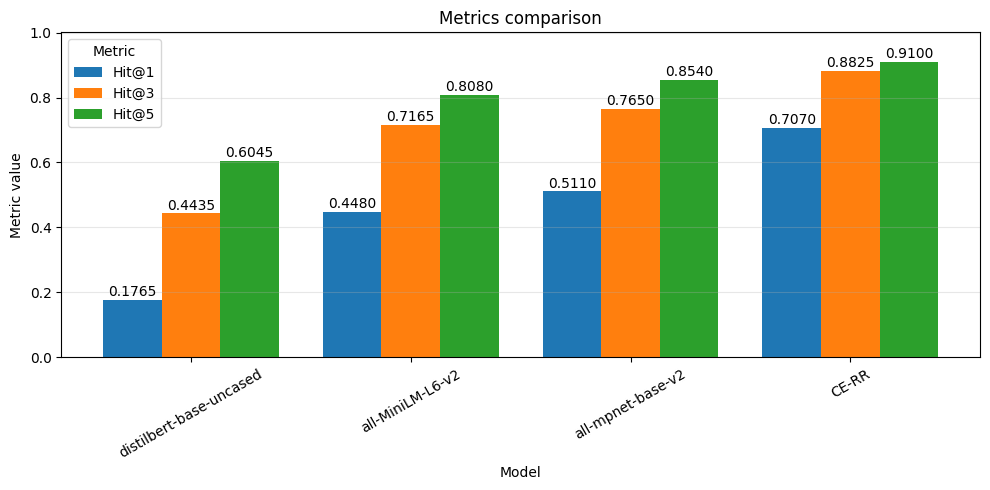

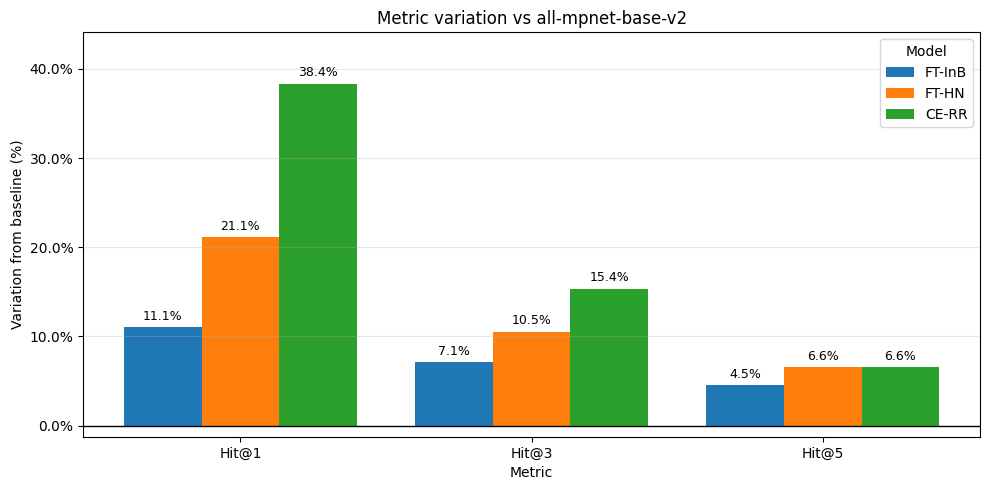

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Metric variation vs all-mpnet-base-v2'}, xlabel='Metric', ylabel='Variation from baseline (%)'>)

In [30]:
# Hit@k percentage variation against the mpnet baseline
mpnet_hit_baseline = make_hit_metric_record("all-mpnet-base-v2", mpnet_baseline_hits_at_k, k_s = k_s)
finetuned_hit_records = [
    make_hit_metric_record("FT-InB", st_hits_at_k, k_s),
    make_hit_metric_record("FT-HN", HN_hits_at_k, k_s),
    make_hit_metric_record("CE-RR", HN_reranked_hits_at_k, k_s),
]



plot_metric_bar_graph(baseline_hit_records + [make_hit_metric_record("CE-RR", HN_reranked_hits_at_k, k_s)])

plot_metric_delta_from_baseline(mpnet_hit_baseline, finetuned_hit_records)


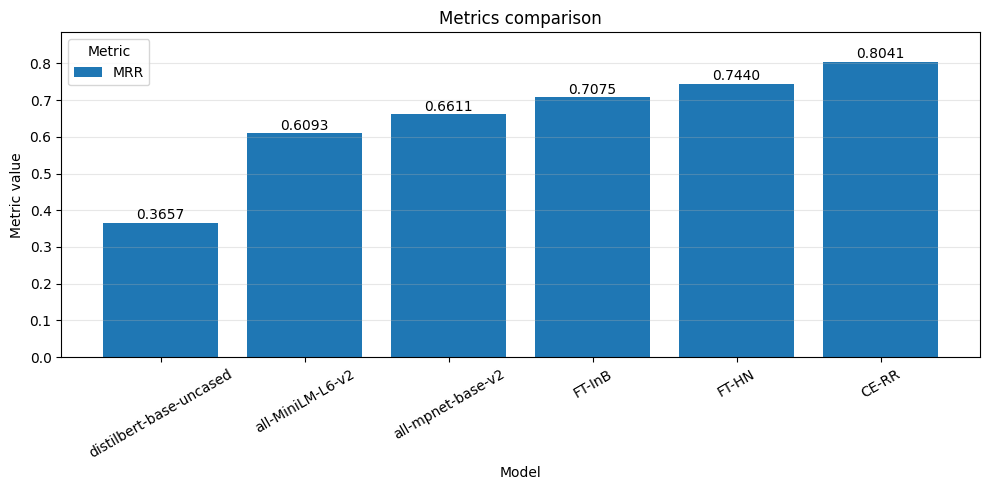

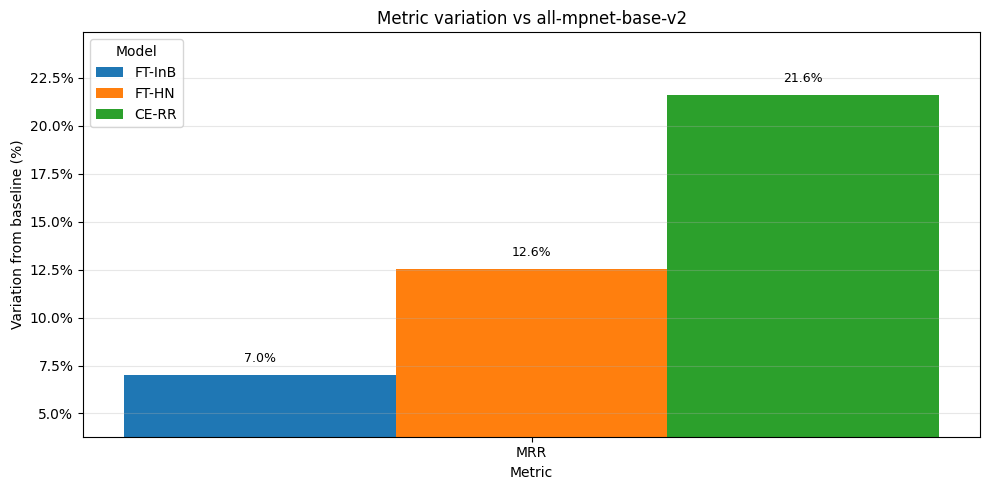

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Metric variation vs all-mpnet-base-v2'}, xlabel='Metric', ylabel='Variation from baseline (%)'>)

In [31]:
# MRR comparison chart between all models
mrr_records = [
    make_mrr_metric_record("distilbert-base-uncased", bert_baseline_mrr),
    make_mrr_metric_record("all-MiniLM-L6-v2", MiniLM_baseline_mrr),
    make_mrr_metric_record("all-mpnet-base-v2", mpnet_baseline_mrr),
    make_mrr_metric_record("FT-InB", st_mrr),
    make_mrr_metric_record("FT-HN", HN_mrr),
    make_mrr_metric_record("CE-RR", HN_reranked_mrr),
]

plot_metric_bar_graph(mrr_records)

# MRR Percent Change from Baseline MPNet
mpnet_mrr_baseline = {
    "model_name": "all-mpnet-base-v2",
    "metrics": [{"metric_name": "MRR", "metric_value": mpnet_baseline_mrr}]
}

mrr_records = [
    {"model_name": "FT-InB", "metrics": [{"metric_name": "MRR", "metric_value": st_mrr}]},
    {"model_name": "FT-HN", "metrics": [{"metric_name": "MRR", "metric_value": HN_mrr}]},
    {"model_name": "CE-RR", "metrics": [{"metric_name": "MRR", "metric_value": HN_reranked_mrr}]},
]

plot_metric_delta_from_baseline(mpnet_mrr_baseline, mrr_records)